In [1]:

import kagglehub

path = kagglehub.dataset_download("andrewmvd/road-sign-detection")

print("Path to dataset files:", path)

import os
os.environ["HF_TOKEN"] = "***************your_huggingface_token***************"  # Replace with your actual Hugging Face token
import io
import shutil
import requests
import matplotlib.pyplot as plt
import numpy as np
from glob import glob
from PIL import Image
from tqdm import tqdm
 
!pip install lxml
from lxml import etree

!pip install ultralytics
from ultralytics import YOLO

!pip install transformers pillow torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
import torch

from PIL import Image, ImageDraw, ImageFont

!pip install pyttsx3
import pyttsx3
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

import torch
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Nazwa karty: {torch.cuda.get_device_name(0)}")

!ls $path

100%|██████████| 218M/218M [00:01<00:00, 134MB/s]  

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/andrewmvd/road-sign-detection/versions/1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.8 MB/s eta 0:00:0000:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Looking in indexes: https://download.pytorch.org/whl/cu121
CUDA: True
Nazwa karty: Tesla T4
annotations  images


In [2]:
def split_train_test(path: str, train_size: float = 0.8, val_size: float = 0.1, seed: int = None):
    if seed is not None:
        np.random.seed(seed)

    annots = np.array(os.listdir(os.path.join(path, "annotations")))
    imgs = np.array(os.listdir(os.path.join(path, "images")))

    annots.sort()
    imgs.sort()

    train_len = int(len(annots) * train_size)
    val_len = int(len(annots) * val_size)
    test_len = len(annots) - train_len - val_len

    indices = np.arange(len(annots), dtype=int)
    np.random.shuffle(indices)

    train_idx = indices[:train_len]
    val_idx = indices[:train_len + val_len]
    test_idx = indices[train_len+val_len:]

    train_annots = annots[train_idx]
    train_imgs = imgs[train_idx]

    val_annots = annots[val_idx]
    val_imgs = imgs[val_idx]

    test_annots = annots[test_idx]
    test_imgs = imgs[test_idx]

    return (train_annots, train_imgs), (val_annots, val_imgs), (test_annots, test_imgs)

In [3]:
train, val, test = split_train_test(path, 0.8, 0.1, seed=42)

In [4]:
def extract_data(xml_file: str):
    tree = etree.parse(xml_file)
    root = tree.getroot()

    img_path = root.find("filename").text

    size = root.find("size")
    width = int(size.find("width").text)
    height = int(size.find("height").text)

    boxes = []
    labels = []

    for obj in root.findall("object"):
        class_name = obj.find("name").text
        bndbox = obj.find("bndbox")

        xmin = int(bndbox.find("xmin").text)
        ymin = int(bndbox.find("ymin").text)
        xmax = int(bndbox.find("xmax").text)
        ymax = int(bndbox.find("ymax").text)

        labels.append(class_name)
        boxes.append([xmin, ymin, xmax, ymax])

    return img_path, width, height, boxes, labels

In [5]:

def rcnn_to_yolo(img_w, img_h, xmin, ymin, xmax, ymax):
    x_abs = (xmin + xmax) / 2
    y_abs = (ymin + ymax) / 2
    w_abs = xmax - xmin
    h_abs = ymax - ymin

    xc = x_abs / img_w
    yc = y_abs / img_h
    w = w_abs / img_w
    h = h_abs / img_h

    return xc, yc, w, h

In [6]:
def create_yolo_files(data: tuple, folder: str):
  os.makedirs(f"{folder}/labels", exist_ok=True)
  os.makedirs(f"{folder}/images", exist_ok=True)

  for (annots, imgs) in data:
    for i in tqdm(range(len(annots))):
      img_path, width, height, boxes, labels = extract_data(os.path.join(path, "annotations", annots[i]))

      result = []
      for j in range(len(boxes)):
         xmin, ymin, xmax, ymax = boxes[j]
         class_id = class_dict[labels[j]]

         box = rcnn_to_yolo(width, height, xmin, ymin, xmax, ymax)
         result.append(f"{class_id} {' '.join(str(x) for x in box)}")

      with open(f"{folder}/labels/{i}.txt", "w") as f:
         content = "\n".join(result)
         f.write(content)

      shutil.copy(os.path.join(path, "images", img_path), f"{folder}/images/{i}.jpg")

In [7]:
class_dict = {"stop": 0, "speedlimit": 1, "crosswalk": 2, "trafficlight": 3}

create_yolo_files([val], "data/val")
create_yolo_files([train], "data/train")
create_yolo_files([test], "data/test")

100%|██████████| 89/89 [00:00<00:00, 1063.15it/s]


In [8]:
def create_yaml(root: str, train: str, valid: str, classes: list):
  """ Create dataset.yaml """
  nc = len(classes)
  content = f"""
path: {root}
train: {train}
val: {valid}

nc: {nc}
names: {classes}
  """
  with open("dataset.yaml", "w") as f:
      f.write(content)
  print("Created dataset.yaml!")

In [9]:
create_yaml("data", "train", "val", list(class_dict.keys()))

Created dataset.yaml!


In [10]:
!cat dataset.yaml


path: data
train: train
val: val

nc: 4
names: ['stop', 'speedlimit', 'crosswalk', 'trafficlight']
  

In [11]:
model = YOLO("yolo26m.pt")

In [12]:
device = "mps" if torch.backends.mps.is_available() else "cpu"

processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-printed')
model_ocr = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-printed').to(device)

class_dict = {"stop": 0, "speedlimit": 1, "crosswalk": 2, "trafficlight": 3}

model.train(data="dataset.yaml", batch=32, epochs=70, imgsz=640, device='gpu',workers=0,plots=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:gpu (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=gpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=70, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b9301e450d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [13]:
best_model = YOLO("runs/detect/train/weights/best.pt")


0: 320x256 1 crosswalk, 1 trafficlight, 11.6ms
1: 320x256 1 speedlimit, 11.6ms
2: 320x256 1 speedlimit, 11.6ms
3: 320x256 1 speedlimit, 11.6ms
4: 320x256 1 speedlimit, 11.6ms
Speed: 0.7ms preprocess, 11.6ms inference, 0.3ms postprocess per image at shape (1, 3, 320, 256)


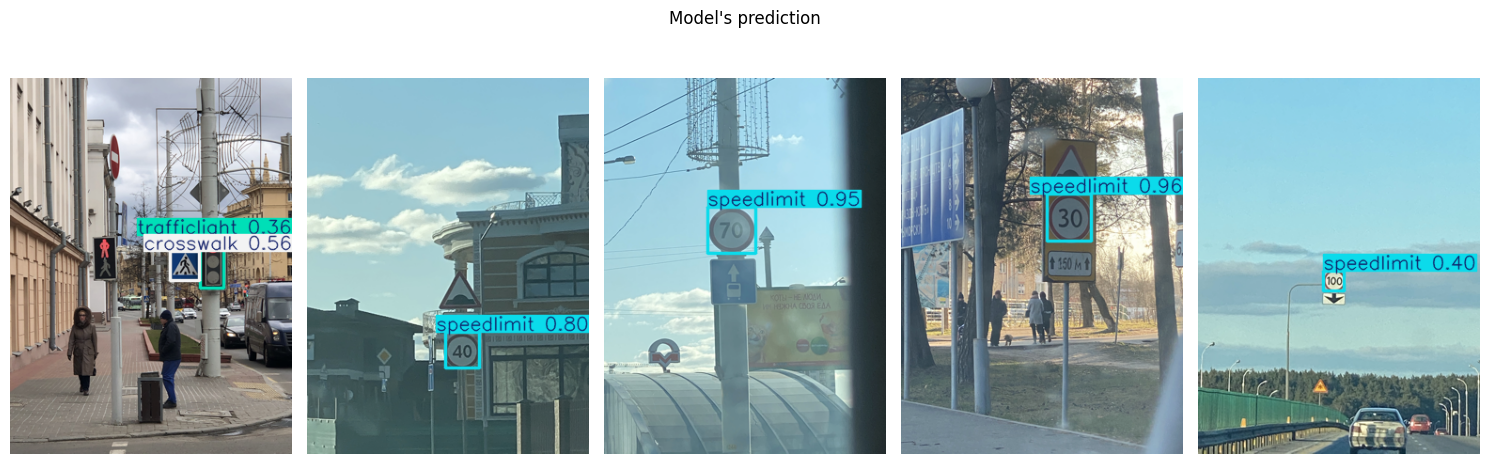

In [14]:
test_imgs = glob("data/test/images/*.jpg")

results = best_model.predict(test_imgs[:5], imgsz=320)

fig, axes = plt.subplots(1, len(results), figsize=(15, 5))

for ax, result in zip(axes, results):
    img = result.plot()  
    ax.imshow(img[:, :, ::-1]) 
    ax.axis("off")

plt.suptitle("Model's prediction")
plt.tight_layout()
plt.show()

In [15]:
def predict_and_show(img_path, yolo_model):
    results = yolo_model.predict(img_path, conf=0.5)
    img = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img)
    
    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            class_id = int(box.cls)
            label = yolo_model.names[class_id]

            if label == 'speedlimit':
                crop = img.crop((max(0, x1-5), max(0, y1-5), x2+5, y2+5))
                
                pixel_values = processor(images=crop, return_tensors="pt").pixel_values.to(device)
                generated_ids = model_ocr.generate(pixel_values)
                text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
                
                clean_text = ''.join(filter(str.isdigit, text))
                display_label = f"Limit: {clean_text}" if clean_text else "Sign"
            else:
                display_label = label

            draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
            draw.text((x1, y1 - 10), display_label, fill="red")
    
    return img


image 1/1 /content/data/test/images/1.jpg: 384x640 1 trafficlight, 55.7ms
Speed: 1.4ms preprocess, 55.7ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)


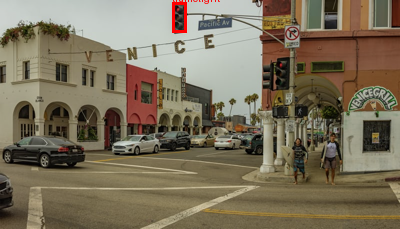

In [17]:
model_path = "runs/detect/train/weights/best.pt"
trained_model = YOLO(model_path)

test_img = "data/test/images/1.jpg" 

result_img = predict_and_show(test_img, trained_model)

display(result_img)

In [21]:
!ls -R runs/detect/

runs/detect/:
train

runs/detect/train:
args.yaml			 labels.jpg		val_batch0_pred.jpg
BoxF1_curve.png			 results.csv		val_batch1_labels.jpg
BoxP_curve.png			 results.png		val_batch1_pred.jpg
BoxPR_curve.png			 train_batch0.jpg	val_batch2_labels.jpg
BoxR_curve.png			 train_batch1.jpg	val_batch2_pred.jpg
confusion_matrix_normalized.png  train_batch2.jpg	weights
confusion_matrix.png		 val_batch0_labels.jpg

runs/detect/train/weights:
best.pt  last.pt


In [ ]:
#zip -r wyniki_yolo.zip runs/detect/*

SyntaxError: invalid syntax (794331268.py, line 1)